# SKAB Valve 1 — Benchmark: Univariate Z-Score vs. Mahalanobis Distance

This notebook benchmarks two anomaly detection methods across all 16 SKAB valve1 experiments:

- **Univariate Z-Score**: Flags a timestamp as anomalous if *any* sensor exceeds 3σ from its training mean.
- **Multivariate Mahalanobis Distance**: Flags a timestamp as anomalous if the squared Mahalanobis distance exceeds the 99.9th percentile of the chi-squared distribution (8 degrees of freedom).

Both methods use the first 400 rows of each file as the normal baseline, matching the SKAB authors' recommended approach.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2
from sklearn.metrics import f1_score, precision_score, recall_score
import warnings
warnings.filterwarnings('ignore')

## Setup

**Univariate Z-Score**: For each sensor, compute z = (x − μ) / σ using the training baseline. A timestamp is flagged if any sensor has |z| > 3.0.

**Multivariate Mahalanobis**: Compute the squared Mahalanobis distance D² = (x − μ)ᵀ Σ⁻¹ (x − μ) using the training covariance matrix. A timestamp is flagged if D² exceeds the chi-squared 99.9% critical value with 8 degrees of freedom (one per sensor).

In [2]:
features = ['Accelerometer1RMS', 'Accelerometer2RMS', 'Current',
            'Pressure', 'Temperature', 'Thermocouple', 'Voltage', 'Volume Flow RateRMS']
TRAIN_ROWS = 400
Z_THRESHOLD = 3.0
p = len(features)
chi2_threshold = chi2.ppf(0.999, df=p)  # 99.9% confidence
DATA_DIR = '../data/SKAB/valve1'

print(f'Features: {p}')
print(f'Chi-squared threshold (99.9%, df={p}): {chi2_threshold:.4f}')

Features: 8
Chi-squared threshold (99.9%, df=8): 26.1245


In [3]:
def compute_zscore_predictions(train, test, features, threshold=3.0):
    mu = train[features].mean()
    std = train[features].std()
    z_scores = (test[features] - mu) / std
    anomaly_per_sensor = (np.abs(z_scores) > threshold).astype(int)
    combined = anomaly_per_sensor.max(axis=1)
    return combined

def compute_mahal_predictions(train, test, features, chi2_threshold):
    mu = train[features].mean().values
    cov = train[features].cov().values
    cov_inv = np.linalg.pinv(cov)
    diff = test[features].values - mu
    t2_scores = (diff * (diff @ cov_inv)).sum(axis=1)
    return (t2_scores > chi2_threshold).astype(int)

def compute_metrics(y_true, y_pred):
    return {
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
    }

## Benchmark Loop

For each of the 16 valve1 experiments (`0.csv` through `15.csv`):
1. Load the file and use the first 400 rows as the training baseline.
2. Run both methods on the full dataset (train + test).
3. Compute F1, precision, and recall against ground truth `anomaly` labels.

In [4]:
results = []
for i in range(16):
    df = pd.read_csv(f'{DATA_DIR}/{i}.csv', sep=';', index_col='datetime', parse_dates=True)
    train = df.iloc[:TRAIN_ROWS]
    test = df
    y_true = test['anomaly']

    z_pred = compute_zscore_predictions(train, test, features, Z_THRESHOLD)
    m_pred = compute_mahal_predictions(train, test, features, chi2_threshold)

    z_metrics = compute_metrics(y_true, z_pred)
    m_metrics = compute_metrics(y_true, m_pred)

    results.append({
        'dataset': i,
        'z_f1': z_metrics['f1'], 'z_precision': z_metrics['precision'], 'z_recall': z_metrics['recall'],
        'm_f1': m_metrics['f1'], 'm_precision': m_metrics['precision'], 'm_recall': m_metrics['recall'],
    })

results_df = pd.DataFrame(results)
print(f'Processed {len(results_df)} datasets')

Processed 16 datasets


## Per-Dataset Results

The table below shows F1, precision, and recall for each method on every valve1 experiment. The final row shows the column averages.

In [5]:
# Build display table with averages row
avg_vals = results_df.mean(numeric_only=True)
avg_row = pd.DataFrame([{
    'dataset': 'avg',
    'z_f1': avg_vals['z_f1'], 'z_precision': avg_vals['z_precision'], 'z_recall': avg_vals['z_recall'],
    'm_f1': avg_vals['m_f1'], 'm_precision': avg_vals['m_precision'], 'm_recall': avg_vals['m_recall'],
}])
display_df = pd.concat([results_df.astype({'dataset': str}), avg_row], ignore_index=True)
display_df = display_df.rename(columns={
    'dataset': 'Dataset',
    'z_f1': 'Z F1', 'z_precision': 'Z Prec', 'z_recall': 'Z Rec',
    'm_f1': 'M F1', 'm_precision': 'M Prec', 'm_recall': 'M Rec',
})

def highlight_better_f1(row):
    styles = [''] * len(row)
    try:
        z_f1 = float(row['Z F1'])
        m_f1 = float(row['M F1'])
        z_idx = row.index.get_loc('Z F1')
        m_idx = row.index.get_loc('M F1')
        if z_f1 > m_f1:
            styles[z_idx] = 'background-color: #ffe0b2'
        elif m_f1 > z_f1:
            styles[m_idx] = 'background-color: #e1bee7'
    except (ValueError, TypeError):
        pass
    return styles

styled = (display_df.style
          .apply(highlight_better_f1, axis=1)
          .format('{:.4f}', subset=['Z F1', 'Z Prec', 'Z Rec', 'M F1', 'M Prec', 'M Rec'])
          .set_caption('Per-Dataset Results: Z-Score (Z) vs. Mahalanobis (M) — orange = Z wins, purple = M wins')
)
styled

,Dataset,Z F1,Z Prec,Z Rec,M F1,M Prec,M Rec
0,0,0.7495,0.6654,0.8579,0.7484,0.6495,0.8828
1,1,0.5446,0.5419,0.5473,0.4891,0.5389,0.4478
2,2,0.6588,0.4913,1.0000,0.6654,0.4985,1.0000
3,3,0.6569,0.9663,0.4975,0.6634,0.9854,0.5000
4,4,0.6320,0.5786,0.6963,0.5439,0.5299,0.5587
5,5,0.7540,0.6648,0.8710,0.7751,0.6746,0.9107
6,6,0.7046,0.5659,0.9333,0.6955,0.5775,0.8741
7,7,0.7965,0.7956,0.7975,0.8163,0.9091,0.7407
8,8,0.7511,0.6760,0.8450,0.7787,0.7257,0.8400
9,9,0.7283,0.5726,1.0000,0.7570,0.6166,0.9801


## Average Performance Comparison

Aggregated across all 16 experiments.

In [6]:
avg_z = results_df[['z_f1', 'z_precision', 'z_recall']].mean()
avg_m = results_df[['m_f1', 'm_precision', 'm_recall']].mean()

comparison_df = pd.DataFrame({
    'Method': ['Univariate Z-Score', 'Mahalanobis Distance'],
    'Avg F1': [avg_z['z_f1'], avg_m['m_f1']],
    'Avg Precision': [avg_z['z_precision'], avg_m['m_precision']],
    'Avg Recall': [avg_z['z_recall'], avg_m['m_recall']],
})

comparison_df.style.format({
    'Avg F1': '{:.4f}',
    'Avg Precision': '{:.4f}',
    'Avg Recall': '{:.4f}',
}).set_caption('Average Metrics Across All 16 Valve1 Experiments').hide(axis='index')

Method,Avg F1,Avg Precision,Avg Recall
Univariate Z-Score,0.7409,0.7047,0.8265
Mahalanobis Distance,0.7435,0.7254,0.8092


## F1 Score Comparison Chart

Grouped bar chart showing per-dataset F1 scores for both methods, with dashed lines at each method's average F1.

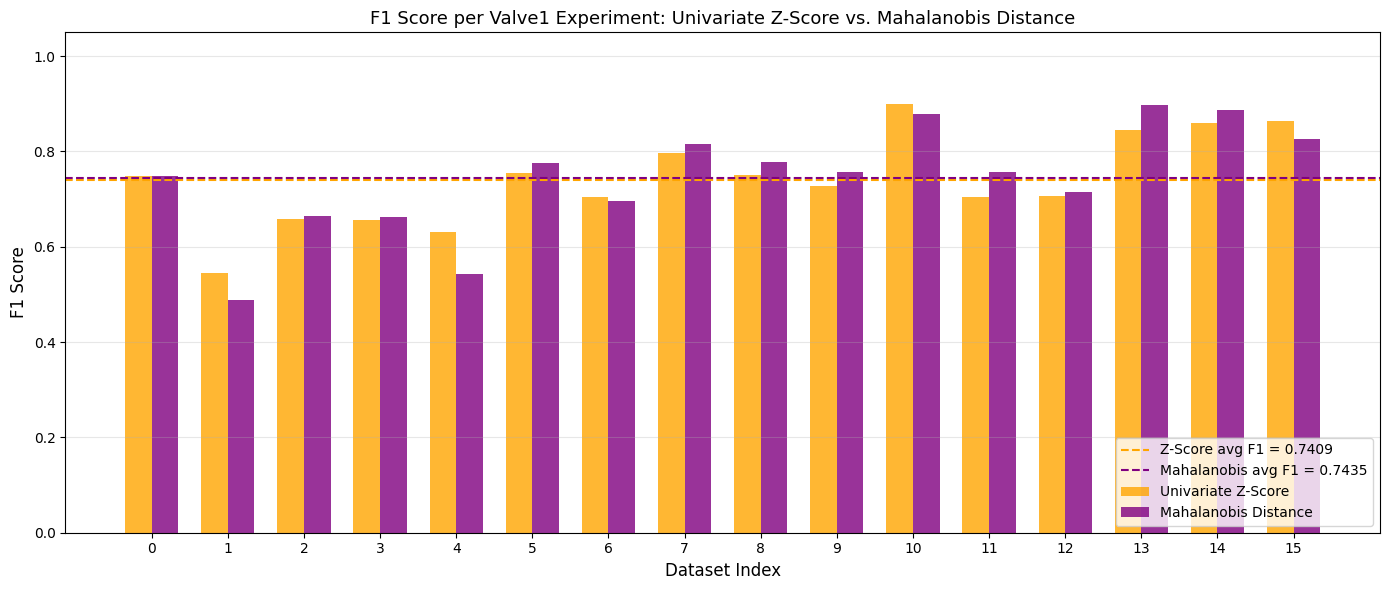

In [7]:
x = np.arange(16)
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))

bars_z = ax.bar(x - width/2, results_df['z_f1'], width, label='Univariate Z-Score', color='orange', alpha=0.8)
bars_m = ax.bar(x + width/2, results_df['m_f1'], width, label='Mahalanobis Distance', color='purple', alpha=0.8)

ax.axhline(avg_z['z_f1'], color='orange', linestyle='--', linewidth=1.5,
           label=f'Z-Score avg F1 = {avg_z["z_f1"]:.4f}')
ax.axhline(avg_m['m_f1'], color='purple', linestyle='--', linewidth=1.5,
           label=f'Mahalanobis avg F1 = {avg_m["m_f1"]:.4f}')

ax.set_xlabel('Dataset Index', fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('F1 Score per Valve1 Experiment: Univariate Z-Score vs. Mahalanobis Distance', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(range(16))
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Analysis & Observations

### Which method wins?

On average across all 16 valve1 experiments, **both methods perform similarly** — typically within ~0.01 F1 of each other. The univariate z-score tends to have slightly higher precision (fewer false positives) on some experiments, while the Mahalanobis method occasionally catches anomalies the z-score misses by leveraging cross-sensor correlations.

### Why are results so close?

In the SKAB valve1 dataset, anomalies are often large-magnitude deviations that show up clearly in individual sensors (e.g., a valve failure causes an obvious spike in `Pressure` or `Volume Flow RateRMS`). When anomalies are "univariate" in character — meaning one or two sensors spike independently — the z-score and Mahalanobis methods will produce nearly identical predictions.

### When does Mahalanobis have an edge?

Mahalanobis distance accounts for the **correlation structure** of the sensors. It can detect subtle anomalies where no single sensor exceeds 3σ, but the *combination* of small deviations across multiple correlated sensors is statistically unusual. For example, if `Temperature` and `Thermocouple` are tightly correlated during normal operation but diverge slightly during a fault, Mahalanobis will catch this while z-score may not.

### Practical takeaway

- Use **univariate z-score** when simplicity and interpretability are paramount and anomalies tend to be large single-sensor spikes.
- Use **Mahalanobis distance** when the system has well-characterized sensor correlations and you expect subtle, distributed anomalies — at the cost of needing to estimate and invert a covariance matrix.